In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
from collections import defaultdict
import numpy as np

import matplotlib.pyplot as plt

import yaml
from pathlib import Path

from thesis_project.datasets import SpeechCommandsGoogle
from thesis_project.utils.paths import get_data_dir

from thesis_project.models.architectures.keyword_spotting import KeyWordSpottingModel, KeyWordSpottingConfig, SpectrogramConfig, BackboneConfig, NoiseConfig

In [20]:
SKIP_TRAINING = False

In [21]:

# --- Load YAML file ---
config_path = Path("/Users/christoffer/Documents/Thesis/thesis_project/src/thesis_project/models/architectures/keyword_spotting/keyword_spotting_config.yaml")
with open(config_path, "r") as f:
    raw_cfg = yaml.safe_load(f)

# --- Parse and validate with Pydantic ---
cfg = KeyWordSpottingConfig(
    spectrogram=SpectrogramConfig(**raw_cfg["spectrogram"]),
    backbone=BackboneConfig(**raw_cfg["backbone"]),
    noise=NoiseConfig(**raw_cfg["noise"]),
    num_classes=raw_cfg.get("num_classes", 35),
)
model = KeyWordSpottingModel(cfg)
data_dir = get_data_dir()
train_set = SpeechCommandsGoogle(root=str(data_dir), subset="training", download=True, **cfg.noise.model_dump())
val_set = SpeechCommandsGoogle(root=str(data_dir), subset="validation", download=True, **cfg.noise.model_dump())

In [22]:
# Training configuration
batch_size = 32
num_epochs = 10
learning_rate = 0.001

torch.manual_seed(42)
np.random.seed(42)

# Device selection: CUDA > MPS > CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS")
else:
    device = torch.device("cpu")
    print("Using CPU")

# Create data loaders (no num_workers for MPS compatibility)
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)

# Move model to device
model = model.to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


Using MPS


In [23]:
def validate_model_per_noise(model, val_loader, criterion, device, noise_params=None,verbose=True):
    """
    Validate the model and report both overall accuracy and accuracy per noise_param value.
    Assumes each batch includes metadata["noise_param"] for every sample.
    """
    if noise_params is None:
        noise_params = cfg.noise.noise_params
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    # Track stats per noise level
    noise_stats = {np: {"correct": 0, "total": 0, "loss": 0.0} for np in noise_params} if noise_params else {}

    with torch.no_grad():
        val_pbar = tqdm(val_loader, desc="Validation")
        for waveforms, labels, meta_data in val_pbar:
            waveforms, labels = waveforms.to(device), labels.to(device)
            
            logits = model(waveforms)
            loss = criterion(logits, labels)

            # Predictions
            _, predicted = torch.max(logits, 1)
            correct = (predicted == labels).sum().item()

            # Update overall stats
            batch_size = labels.size(0)
            val_total += batch_size
            val_correct += correct
            val_loss += loss.item() * batch_size

            # Update per-noise stats
            noise_params_batch = meta_data["noise_param"] if isinstance(meta_data, dict) else [m["noise_param"] for m in meta_data]
            for i, noise_param in enumerate(noise_params_batch):
                noise_stats[float(noise_param)]["total"] += 1
                noise_stats[float(noise_param)]["correct"] += int(predicted[i] == labels[i])
                noise_stats[float(noise_param)]["loss"] += loss.item()

            # Progress bar
            val_pbar.set_postfix({
                "loss": f"{loss.item():.4f}",
                "acc": f"{100 * val_correct / val_total:.2f}%"
            })

    # Compute averages
    val_loss /= val_total
    val_acc = 100 * val_correct / val_total

    # Compute per-noise accuracy/loss
    per_noise = {
        np: {
            "acc": 100 * v["correct"] / v["total"] if v["total"] > 0 else 0.0,
            "loss": v["loss"] / v["total"] if v["total"] > 0 else 0.0,
        }
        for np, v in sorted(noise_stats.items())
    }
    if verbose:
        # Print or return as you prefer
        print("\n=== Accuracy per noise_param ===")
        for np, v in per_noise.items():
            print(f"  noise={np:>6}: acc={v['acc']:.2f}%  loss={v['loss']:.4f}")

    return val_loss, val_acc, per_noise

In [24]:
if not SKIP_TRAINING:
    # Training loop
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
        for waveforms, labels, _ in train_pbar:  # Dataset returns (waveform, label, metadata)
            waveforms, labels = waveforms.to(device), labels.to(device)
            
            # Forward pass
            optimizer.zero_grad()
            logits = model(waveforms)
            loss = criterion(logits, labels)
            
            # Backward pass and optimization
            loss.backward()
            optimizer.step()
            
            # Statistics
            train_loss += loss.item() * waveforms.size(0)
            _, predicted = torch.max(logits, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
            
            # Update progress bar
            train_pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{100 * train_correct / train_total:.2f}%'
            })
        
        train_loss = train_loss / len(train_set)
        train_acc = 100 * train_correct / train_total
        
        # Validation phase

        val_loss, val_acc, per_noise = validate_model_per_noise(model, val_loader, criterion, device,verbose=False)

        # Print epoch summary
        print(f"\nEpoch {epoch+1}/{num_epochs} Summary:")
        print(f"  Train Loss: {train_loss:.4f}, Train Acc (Micro): {train_acc:.2f}%")
        print(f"  Val Loss: {val_loss:.4f}, Val Acc (Micro): {val_acc:.2f}%")
        # Print or return as you prefer
        print("\n=== Val Accuracy per noise_param ===")
        for np, v in per_noise.items():
            print(f"  noise={np:>6}: acc={v['acc']:.2f}%  loss={v['loss']:.4f}")
        print("-" * 60)

    print("Training completed!")
    # save the model
    torch.save(model.state_dict(), "keyword_spotting_model.pth")

Validation: 100%|██████████| 312/312 [00:11<00:00, 28.05it/s, loss=1.9451, acc=33.63%]



Epoch 1/10 Summary:
  Train Loss: 3.3847, Train Acc (Micro): 16.07%
  Val Loss: 2.3704, Val Acc (Micro): 33.63%

=== Val Accuracy per noise_param ===
  noise=   0.0: acc=40.18%  loss=2.3722
  noise=  0.05: acc=45.64%  loss=2.3719
  noise=   0.1: acc=38.93%  loss=2.3736
  noise=  0.15: acc=30.43%  loss=2.3694
  noise=   0.2: acc=24.62%  loss=2.3666
  noise=  0.25: acc=21.68%  loss=2.3687
------------------------------------------------------------


Validation: 100%|██████████| 312/312 [00:11<00:00, 26.80it/s, loss=1.8738, acc=46.63%]



Epoch 2/10 Summary:
  Train Loss: 2.2510, Train Acc (Micro): 38.50%
  Val Loss: 1.9098, Val Acc (Micro): 46.63%

=== Val Accuracy per noise_param ===
  noise=   0.0: acc=53.81%  loss=1.9157
  noise=  0.05: acc=59.92%  loss=1.9123
  noise=   0.1: acc=53.03%  loss=1.9108
  noise=  0.15: acc=45.29%  loss=1.9061
  noise=   0.2: acc=36.78%  loss=1.9049
  noise=  0.25: acc=30.59%  loss=1.9089
------------------------------------------------------------


Validation: 100%|██████████| 312/312 [00:11<00:00, 26.83it/s, loss=1.7816, acc=50.98%]


...


Epoch 8/10 Summary:
  Train Loss: 1.6605, Train Acc (Micro): 54.86%
  Val Loss: 1.4651, Val Acc (Micro): 58.99%

=== Val Accuracy per noise_param ===
  noise=   0.0: acc=74.11%  loss=1.4681
  noise=  0.05: acc=72.28%  loss=1.4671
  noise=   0.1: acc=64.91%  loss=1.4661
  noise=  0.15: acc=55.80%  loss=1.4624
  noise=   0.2: acc=46.70%  loss=1.4615
  noise=  0.25: acc=39.67%  loss=1.4651
------------------------------------------------------------


Validation: 100%|██████████| 312/312 [00:11<00:00, 26.95it/s, loss=1.3373, acc=59.80%]



Epoch 9/10 Summary:
  Train Loss: 1.6168, Train Acc (Micro): 56.04%
  Val Loss: 1.4549, Val Acc (Micro): 59.80%

=== Val Accuracy per noise_param ===
  noise=   0.0: acc=78.45%  loss=1.4562
  noise=  0.05: acc=73.36%  loss=1.4560
  noise=   0.1: acc=64.37%  loss=1.4558
  noise=  0.15: acc=55.86%  loss=1.4532
  noise=   0.2: acc=46.88%  loss=1.4528
  noise=  0.25: acc=39.37%  loss=1.4551
------------------------------------------------------------


Validation: 100%|██████████| 312/312 [00:11<00:00, 26.70it/s, loss=1.0221, acc=62.73%]



Epoch 10/10 Summary:
  Train Loss: 1.6004, Train Acc (Micro): 56.20%
  Val Loss: 1.2861, Val Acc (Micro): 62.73%

=== Val Accuracy per noise_param ===
  noise=   0.0: acc=85.77%  loss=1.2892
  noise=  0.05: acc=75.15%  loss=1.2874
  noise=   0.1: acc=66.41%  loss=1.2864
  noise=  0.15: acc=58.03%  loss=1.2833
  noise=   0.2: acc=47.43%  loss=1.2834
  noise=  0.25: acc=43.00%  loss=1.2866
------------------------------------------------------------
Training completed!


In [25]:
# load the model
model.load_state_dict(torch.load("keyword_spotting_model.pth"))

<All keys matched successfully>

In [26]:
def validate_model_per_noise(model, val_loader, criterion, device, noise_params=None,verbose=True):
    """
    Validate the model and report both overall accuracy and accuracy per noise_param value.
    Assumes each batch includes metadata["noise_param"] for every sample.
    """
    if noise_params is None:
        noise_params = cfg.noise.noise_params
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    # Track stats per noise level
    noise_stats = {np: {"correct": 0, "total": 0, "loss": 0.0} for np in noise_params} if noise_params else {}

    with torch.no_grad():
        val_pbar = tqdm(val_loader, desc="Validation")
        for waveforms, labels, meta_data in val_pbar:
            waveforms, labels = waveforms.to(device), labels.to(device)
            
            logits = model(waveforms)
            loss = criterion(logits, labels)

            # Predictions
            _, predicted = torch.max(logits, 1)
            correct = (predicted == labels).sum().item()

            # Update overall stats
            batch_size = labels.size(0)
            val_total += batch_size
            val_correct += correct
            val_loss += loss.item() * batch_size

            # Update per-noise stats
            noise_params_batch = meta_data["noise_param"] if isinstance(meta_data, dict) else [m["noise_param"] for m in meta_data]
            for i, noise_param in enumerate(noise_params_batch):
                noise_stats[float(noise_param)]["total"] += 1
                noise_stats[float(noise_param)]["correct"] += int(predicted[i] == labels[i])
                noise_stats[float(noise_param)]["loss"] += loss.item()

            # Progress bar
            val_pbar.set_postfix({
                "loss": f"{loss.item():.4f}",
                "acc": f"{100 * val_correct / val_total:.2f}%"
            })

    # Compute averages
    val_loss /= val_total
    val_acc = 100 * val_correct / val_total

    # Compute per-noise accuracy/loss
    per_noise = {
        np: {
            "acc": 100 * v["correct"] / v["total"] if v["total"] > 0 else 0.0,
            "loss": v["loss"] / v["total"] if v["total"] > 0 else 0.0,
        }
        for np, v in sorted(noise_stats.items())
    }
    if verbose:
        # Print or return as you prefer
        print("\n=== Accuracy per noise_param ===")
        for np, v in per_noise.items():
            print(f"  noise={np:>6}: acc={v['acc']:.2f}%  loss={v['loss']:.4f}")

    return val_loss, val_acc, per_noise

In [27]:
val_loss, val_acc, per_noise = validate_model_per_noise(model, val_loader, criterion, device)
print(f"Final Validation Loss: {val_loss:.4f}, Final Validation Acc: {val_acc:.2f}%")

Validation: 100%|██████████| 312/312 [00:11<00:00, 26.41it/s, loss=1.2200, acc=62.54%]


=== Accuracy per noise_param ===
  noise=   0.0: acc=85.77%  loss=1.3066
  noise=  0.05: acc=75.75%  loss=1.3029
  noise=   0.1: acc=66.77%  loss=1.3023
  noise=  0.15: acc=57.13%  loss=1.2993
  noise=   0.2: acc=48.64%  loss=1.2983
  noise=  0.25: acc=40.58%  loss=1.3033
Final Validation Loss: 1.3021, Final Validation Acc: 62.54%


In [ ]:
def evaluate_rank_sweep(
    model,
    compressible_layers,
    validate_fn,
    val_loader,
    criterion,
    device,
    max_rank,
    step=4,
    compress_frontend=False,
    verbose=True,
):
    """
    Sweep across target ranks for CPC_Conv1d layers and record validation accuracy.

    Args:
        model (nn.Module): Your model containing CPC_Conv1d layers.
        compressible_layers (list[tuple[str, nn.Module]]): (name, layer) pairs of CPC_Conv1d layers.
        validate_fn (callable): Validation function (model, val_loader, criterion, device) -> (val_loss, val_acc)
        val_loader (DataLoader): Validation dataloader.
        criterion (nn.Module): Loss function.
        device (torch.device): Torch device.
        max_rank (int): Maximum rank (usually = in_channels = out_channels).
        step (int, optional): Step size for the rank sweep. Default = 4.
        compress_frontend (bool, optional): If False, skip compressing the "frontend" layer.
        verbose (bool, optional): Print progress messages.

    Returns:
        list[tuple[int, float]]: List of (target_rank, val_acc) results.
    """
    val_acc_results = []

    for target_rank in range(step, max_rank + 1, step):
        # --- Activate low-rank ---
        for name, layer in compressible_layers:
            if (not compress_frontend) and (name == "frontend"):
                continue
            layer.activate_low_rank(rank=target_rank)

        # --- Validate ---
        val_loss, val_acc, per_noise = validate_fn(model, val_loader, criterion, device, verbose=False)
        val_acc_results.append((target_rank, per_noise))

        if verbose:
            print(f"[Rank {target_rank:>3}] Val Acc: {val_acc:.3f}")
            for np, v in per_noise.items():
                print(f"  noise={np:>6}: acc={v['acc']:.2f}%  loss={v['loss']:.4f}")

    return val_acc_results


In [33]:
def plot_rank_vs_accuracy_by_noise(
    results,                 # list of (rank: int, per_noise: dict[noise_param -> {'acc': float, 'loss': float}])
    title=None,
    save_path=None,
    metric="acc",            # "acc" or "loss"
    show_flops=True,         # keep the secondary y-axis like before
):
    """
    Plot {metric} vs. rank with one curve per noise_param.

    Example input:
    results = [
        (4, {0.0:{'acc':14.76,'loss':4.07}, 0.05:{'acc':21.62,'loss':4.06}}),
        (8, {0.0:{'acc':20.65,'loss':4.06}, 0.05:{'acc':34.11,'loss':4.05}})
    ]
    """

    # --- collect and sort ranks ---
    ranks = sorted(int(r) for r, _ in results)
    rank_to_dict = {int(r): d for r, d in results}

    # --- gather all noise params across ranks ---
    all_noise = set()
    for d in rank_to_dict.values():
        for k in d.keys():
            try:
                all_noise.add(float(k))
            except Exception:
                # ignore non-numeric noise keys
                pass
    noise_params = sorted(all_noise)  # numeric sort

    # --- build series per noise param aligned to 'ranks' order ---
    series = {}  # noise_param -> list of metric values aligned with ranks
    for np_val in noise_params:
        vals = []
        for r in ranks:
            entry = rank_to_dict[r].get(np_val, None)
            if entry is None or metric not in entry:
                vals.append(np.nan)  # missing value creates a gap in the curve
            else:
                vals.append(entry[metric])
        series[np_val] = vals

    # --- relative FLOPs for PW conv (same as your original logic) ---
    C = max(ranks) if ranks else 1
    flops_rel = [2 * r / C for r in ranks]  # =1 when r=C/2

    # --- plot ---
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # left axis: metric per noise
    for np_val, vals in series.items():
        ax1.plot(ranks, vals, marker='o', label=f"noise std={np_val:g}")

    ax1.set_xlabel("Target Rank")
    ylab = "Validation Accuracy (%)" if metric == "acc" else "Validation Loss"
    ax1.set_ylabel(ylab)
    ax1.grid(True, alpha=0.4)

    # helpful vertical reference at C//2
    ax1.axvline(x=C // 2, color='r', linestyle='--', linewidth=1, label='Max Rank // 2')

    # right axis: relative FLOPs (optional)
    if show_flops:
        ax2 = ax1.twinx()
        ax2.plot(ranks, flops_rel, linestyle='-', alpha=0.6, label="Relative PW FLOPs")
        ax2.set_ylabel("Relative PW FLOPs (vs full conv)")
        # Handle legends from both axes
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")
    else:
        ax1.legend(loc="best")

    # title
    if title is None:
        base = "Validation Accuracy vs. Target Rank" if metric == "acc" \
               else "Validation Loss vs. Target Rank"
        if show_flops:
            base += " (with Relative PW FLOPs)"
        title = base
    plt.title(title)

    # save or show
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        print(f"Plot saved to {save_path}")
        plt.close(fig)
    else:
        plt.tight_layout()
        plt.show()


In [34]:
from thesis_project.models.blocks import CPC_Conv1d
compressible_layers = []
for name, layer in model.named_modules():
    if isinstance(layer, CPC_Conv1d):
        W = layer.weight_full.squeeze(-1)
        max_rank = min(W.shape)
        print(f"{name}: max_rank = {max_rank}")
        compressible_layers.append((name, layer))

backbone.0.0.cpw_conv1: max_rank = 128
backbone.0.0.cpw_conv2: max_rank = 128
backbone.0.1.cpw_conv1: max_rank = 128
backbone.0.1.cpw_conv2: max_rank = 128
backbone.0.2.cpw_conv1: max_rank = 128
backbone.0.2.cpw_conv2: max_rank = 128
backbone.1.0.cpw_conv1: max_rank = 128
backbone.1.0.cpw_conv2: max_rank = 128
backbone.1.1.cpw_conv1: max_rank = 128
backbone.1.1.cpw_conv2: max_rank = 128
backbone.1.2.cpw_conv1: max_rank = 128
backbone.1.2.cpw_conv2: max_rank = 128
frontend: max_rank = 128


In [35]:
results = {}

results["val_acc_results"] = evaluate_rank_sweep(
    model=model,
    compressible_layers=compressible_layers,
    validate_fn=validate_model_per_noise,
    val_loader=val_loader,
    criterion=criterion,    
    device=device,
    max_rank=128, #128
    step=4,
    compress_frontend=False,
    verbose=True
)

Validation: 100%|██████████| 312/312 [00:13<00:00, 23.38it/s, loss=3.8594, acc=9.32%] 



=== Accuracy per noise_param ===
  noise=   0.0: acc=7.80%  loss=5.0964
  noise=  0.05: acc=11.35%  loss=5.0850
  noise=   0.1: acc=11.40%  loss=5.0853
  noise=  0.15: acc=10.63%  loss=5.0728
  noise=   0.2: acc=7.80%  loss=5.0667
  noise=  0.25: acc=6.90%  loss=5.0855
[Rank   4] Val Acc: 9.318


Validation: 100%|██████████| 312/312 [00:12<00:00, 25.42it/s, loss=2.8449, acc=24.82%]



=== Accuracy per noise_param ===
  noise=   0.0: acc=28.39%  loss=3.4450
  noise=  0.05: acc=36.62%  loss=3.4391
  noise=   0.1: acc=29.57%  loss=3.4339
  noise=  0.15: acc=21.86%  loss=3.4233
  noise=   0.2: acc=18.09%  loss=3.4232
  noise=  0.25: acc=14.11%  loss=3.4344
[Rank   8] Val Acc: 24.817


Validation: 100%|██████████| 312/312 [00:12<00:00, 24.25it/s, loss=1.9891, acc=36.72%]


...


=== Accuracy per noise_param ===
  noise=   0.0: acc=85.77%  loss=1.2994
  noise=  0.05: acc=74.91%  loss=1.2961
  noise=   0.1: acc=66.53%  loss=1.2957
  noise=  0.15: acc=58.76%  loss=1.2924
  noise=   0.2: acc=48.15%  loss=1.2929
  noise=  0.25: acc=42.16%  loss=1.2975
[Rank 120] Val Acc: 62.809


Validation: 100%|██████████| 312/312 [00:11<00:00, 26.71it/s, loss=1.0925, acc=63.00%]



=== Accuracy per noise_param ===
  noise=   0.0: acc=85.77%  loss=1.3003
  noise=  0.05: acc=75.81%  loss=1.2969
  noise=   0.1: acc=66.41%  loss=1.2956
  noise=  0.15: acc=58.76%  loss=1.2921
  noise=   0.2: acc=47.91%  loss=1.2918
  noise=  0.25: acc=42.76%  loss=1.2969
[Rank 124] Val Acc: 63.000


Validation: 100%|██████████| 312/312 [00:11<00:00, 26.41it/s, loss=0.9202, acc=63.31%]


=== Accuracy per noise_param ===
  noise=   0.0: acc=85.77%  loss=1.3025
  noise=  0.05: acc=76.58%  loss=1.2998
  noise=   0.1: acc=67.43%  loss=1.2986
  noise=  0.15: acc=58.27%  loss=1.2968
  noise=   0.2: acc=48.15%  loss=1.2956
  noise=  0.25: acc=43.06%  loss=1.2998
[Rank 128] Val Acc: 63.310


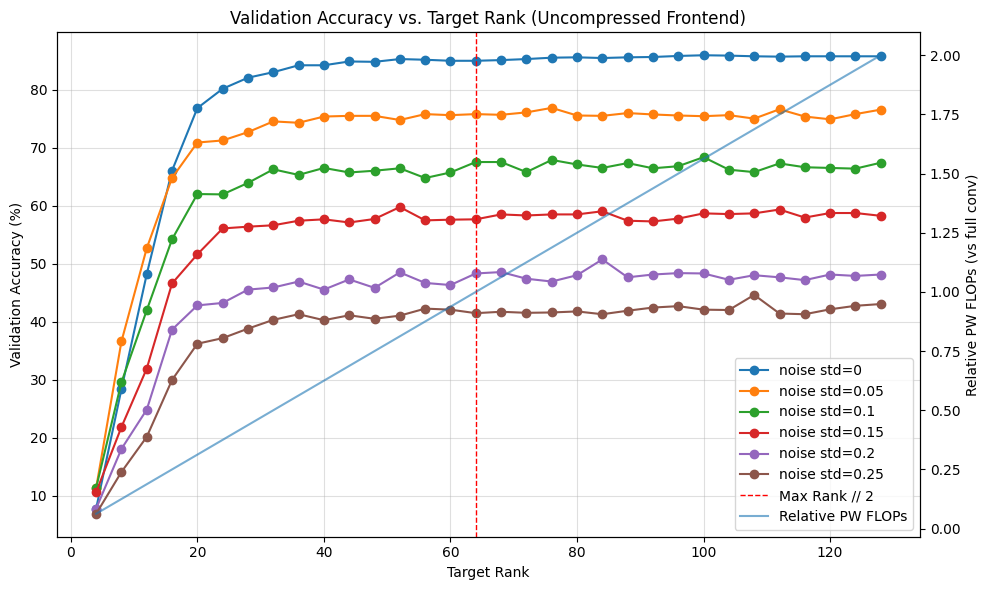

In [36]:
plot_rank_vs_accuracy_by_noise(
    results=results["val_acc_results"],
    title="Validation Accuracy vs. Target Rank (Uncompressed Frontend)",
    metric="acc",
    show_flops=True
)

### COMPRESSED FRONTEND RESULTS

In [37]:
results["val_acc_results_compressed_frontend"] = evaluate_rank_sweep(
    model=model,
    compressible_layers=compressible_layers,
    validate_fn=validate_model_per_noise,
    val_loader=val_loader,
    criterion=criterion,    
    device=device,
    max_rank=128, #128
    step=4,
    compress_frontend=True,
    verbose=True
)

Validation:   0%|          | 0/312 [00:00<?, ?it/s]

Validation: 100%|██████████| 312/312 [00:11<00:00, 26.27it/s, loss=4.4584, acc=6.70%] 



=== Accuracy per noise_param ===
  noise=   0.0: acc=5.18%  loss=4.6187
  noise=  0.05: acc=6.09%  loss=4.6107
  noise=   0.1: acc=7.14%  loss=4.6141
  noise=  0.15: acc=7.31%  loss=4.6055
  noise=   0.2: acc=6.90%  loss=4.6027
  noise=  0.25: acc=7.63%  loss=4.6110
[Rank   4] Val Acc: 6.703


Validation: 100%|██████████| 312/312 [00:12<00:00, 25.83it/s, loss=2.3949, acc=13.24%]



=== Accuracy per noise_param ===
  noise=   0.0: acc=17.50%  loss=3.9876
  noise=  0.05: acc=21.03%  loss=3.9845
  noise=   0.1: acc=13.68%  loss=3.9818
  noise=  0.15: acc=11.41%  loss=3.9735
  noise=   0.2: acc=8.29%  loss=3.9699
  noise=  0.25: acc=7.33%  loss=3.9802
[Rank   8] Val Acc: 13.235


...


=== Accuracy per noise_param ===
  noise=   0.0: acc=86.01%  loss=1.2920
  noise=  0.05: acc=76.16%  loss=1.2897
  noise=   0.1: acc=68.21%  loss=1.2889
  noise=  0.15: acc=58.57%  loss=1.2874
  noise=   0.2: acc=47.55%  loss=1.2876
  noise=  0.25: acc=42.10%  loss=1.2902
[Rank 120] Val Acc: 63.200


Validation: 100%|██████████| 312/312 [00:11<00:00, 26.27it/s, loss=1.0023, acc=63.17%]



=== Accuracy per noise_param ===
  noise=   0.0: acc=85.95%  loss=1.2940
  noise=  0.05: acc=76.34%  loss=1.2909
  noise=   0.1: acc=66.17%  loss=1.2919
  noise=  0.15: acc=57.85%  loss=1.2900
  noise=   0.2: acc=49.12%  loss=1.2888
  noise=  0.25: acc=43.00%  loss=1.2919
[Rank 124] Val Acc: 63.170


Validation: 100%|██████████| 312/312 [00:11<00:00, 26.04it/s, loss=1.0073, acc=62.46%]


=== Accuracy per noise_param ===
  noise=   0.0: acc=85.77%  loss=1.2998
  noise=  0.05: acc=76.40%  loss=1.2970
  noise=   0.1: acc=66.95%  loss=1.2967
  noise=  0.15: acc=56.52%  loss=1.2957
  noise=   0.2: acc=47.67%  loss=1.2950
  noise=  0.25: acc=40.82%  loss=1.2977
[Rank 128] Val Acc: 62.459


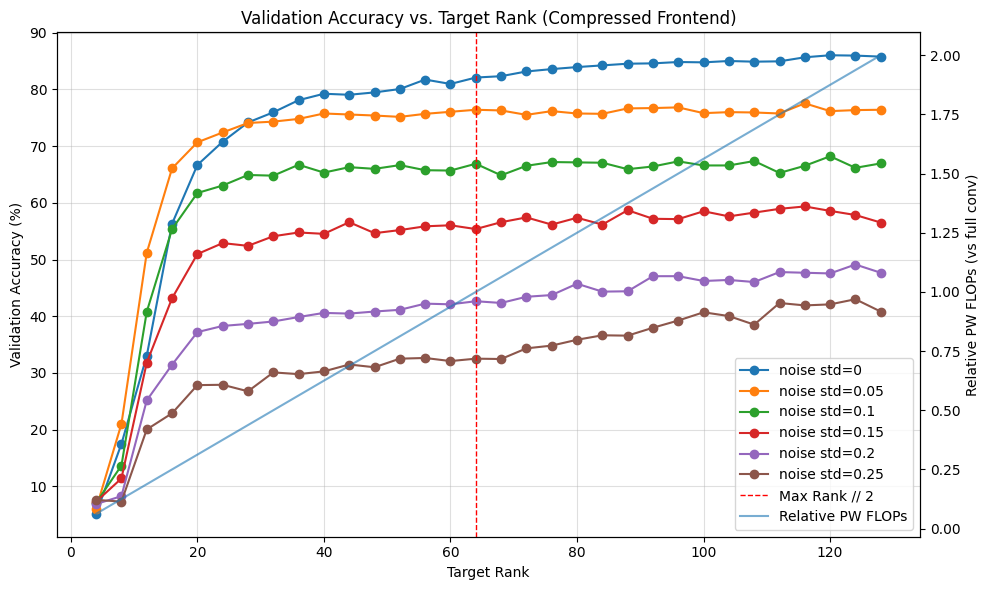

In [38]:
plot_rank_vs_accuracy_by_noise(
    results=results["val_acc_results_compressed_frontend"],
    title="Validation Accuracy vs. Target Rank (Compressed Frontend)",
    metric="acc",
    show_flops=True
)